# 1D heat equation: forward vs. backward Euler

Solves the heat equation from `ex:heat_equation`
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \qquad x \in [0,1], \quad t \in [0,1],
$$
with zero Dirichlet boundary conditions $u(t,0) = u(t,1) = 0$ and a skinny Gaussian bump as the initial condition, using centered differences in space and comparing forward Euler (explicit) and backward Euler (implicit) time stepping on the same grid.

Centered differences turn the spatial derivative into
$$
\frac{\partial^2 u}{\partial x^2}(t, x_i) \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2},
$$
and with $r = \alpha \Delta t / \Delta x^2$, forward Euler is only stable for $r \le 1/2$ while backward Euler is unconditionally stable. We deliberately pick $r$ slightly above $1/2$ to see forward Euler blow up while backward Euler remains well behaved.

In [1]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import matplotlib.pyplot as plt

In [2]:
# domain [0,1] x [0,1] and diffusivity
L, T = 1.0, 1.0
alpha = 1.0

# grid: chosen so that r = alpha*dt/dx^2 is just above the forward Euler stability limit of 1/2
Nx = 51
Nt = 4000
x = np.linspace(0, L, Nx)
dx = x[1] - x[0]
dt = T / Nt
r = alpha * dt / dx**2
print(f"dx = {dx:.4f}, dt = {dt:.6f}, r = {r:.3f} (unstable for forward Euler since r > 0.5)")

dx = 0.0200, dt = 0.000250, r = 0.625 (unstable for forward Euler since r > 0.5)


In [3]:
# initial condition: skinny Gaussian bump, sigma = 0.1, centered in the domain
sigma = 0.1
u0 = np.exp(-(x - 0.5) ** 2 / (2 * sigma**2))
u0[0] = 0.0
u0[-1] = 0.0

In [4]:
def forward_euler_heat(u0, r, Nt, blow_up_level=50.0):
    """Explicit forward Euler in time, centered differences in space.

    Stops early once the solution exceeds a sensible physical magnitude,
    since the whole point here is that this scheme is unstable and the
    remaining steps would only diverge further.
    """
    u = u0.copy()
    snapshots = [u.copy()]
    with np.errstate(over="ignore", invalid="ignore"):
        for n in range(Nt):
            u_new = u.copy()
            u_new[1:-1] = u[1:-1] + r * (u[2:] - 2 * u[1:-1] + u[:-2])
            u = u_new
            snapshots.append(u.copy())
            if not np.all(np.isfinite(u)) or np.max(np.abs(u)) > blow_up_level:
                break
    return np.array(snapshots)


def backward_euler_heat(u0, r, Nt, save_every=1):
    """Implicit backward Euler in time, centered differences in space."""
    n_int = u0.size - 2
    A = (
        (1 + 2 * r) * np.eye(n_int)
        - r * np.eye(n_int, k=1)
        - r * np.eye(n_int, k=-1)
    )
    lu, piv = lu_factor(A)

    u = u0.copy()
    snapshots = [u.copy()]
    for n in range(Nt):
        u = u.copy()
        u[1:-1] = lu_solve((lu, piv), u[1:-1])
        if (n + 1) % save_every == 0:
            snapshots.append(u.copy())
    return np.array(snapshots)

In [5]:
save_every_be = 40
t_be = np.arange(0, Nt + 1, save_every_be) * dt
U_be = backward_euler_heat(u0, r, Nt, save_every=save_every_be)

# forward Euler is run at every step and stopped as soon as it exceeds a
# sensible magnitude, since it diverges almost immediately once it violates
# the CFL condition -- the interesting part is exactly how fast this happens
blow_up_level = 50.0
U_fe = forward_euler_heat(u0, r, Nt, blow_up_level=blow_up_level)
t_fe = np.arange(U_fe.shape[0]) * dt
U_fe_masked = np.where(np.abs(U_fe) > blow_up_level, np.nan, U_fe)

print(f"forward Euler ran {U_fe.shape[0] - 1} steps before exceeding |u| = {blow_up_level} "
      f"(t = {t_fe[-1]:.4f}), out of {Nt} steps needed to reach t = {T}")

forward Euler ran 56 steps before exceeding |u| = 50.0 (t = 0.0140), out of 4000 steps needed to reach t = 1.0


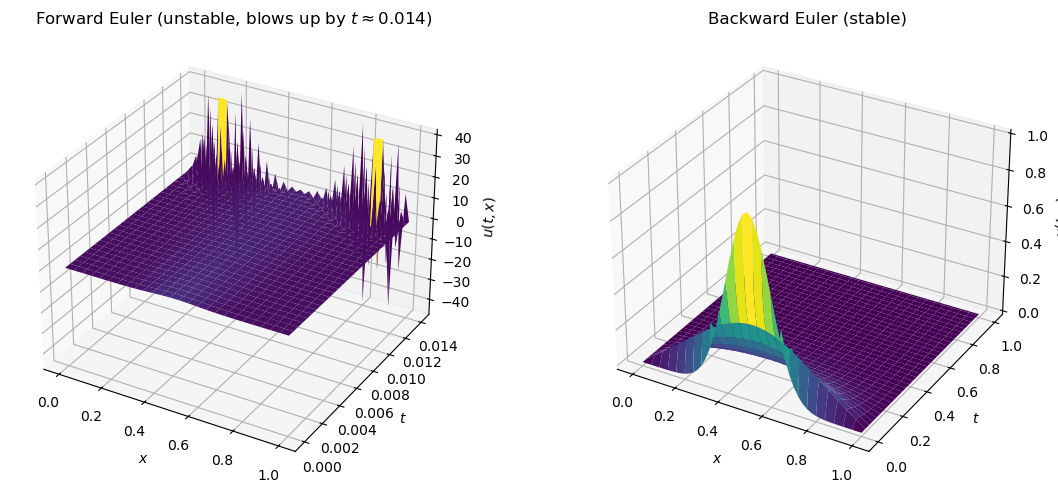

In [6]:
X_fe, Tg_fe = np.meshgrid(x, t_fe)
X_be, Tg_be = np.meshgrid(x, t_be)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X_fe, Tg_fe, U_fe_masked, cmap="viridis")
ax1.set_xlabel("$x$")
ax1.set_ylabel("$t$")
ax1.set_zlabel("$u(t,x)$")
ax1.set_title(f"Forward Euler (unstable, blows up by $t\\approx${t_fe[-1]:.3f})")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(X_be, Tg_be, U_be, cmap="viridis")
ax2.set_xlabel("$x$")
ax2.set_ylabel("$t$")
ax2.set_zlabel("$u(t,x)$")
ax2.set_title("Backward Euler (stable)")

fig.tight_layout()
fig.savefig("heat_equation.png", dpi=300, bbox_inches="tight")
plt.show()